# Imports

In [1]:
import os
import numpy as np
import pingouin as pg
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats as stats
from pathlib import Path
from matplotlib.ticker import MultipleLocator
from scipy.stats import shapiro
from scipy.stats import gaussian_kde

# Display

In [2]:
pd.set_option("display.max_columns", None)   # show all columns
pd.set_option("display.width", None)         # auto-detect full width
pd.set_option("display.expand_frame_repr", False)  # prevent line wrapping

# Grand Average(s)

In [4]:
# Base folder
data_folder = "GA"

# Files for each condition
csv_files = {
    "ALL" : "GA_ALL_3.csv",
    "Condition NST": "GA_NST_3.csv",
    "Condition SNT": "GA_SNT_3.csv",
    "Condition ST": "GA_ST_3.csv"
}

tmin = -100   # ms
tmax = 500    # ms

In [5]:
def load_eeg_subset(file_path, channels_of_interest):
    """
    Load EEG CSV and extract selected channels.

    Returns
    -------
    data_subset : np.ndarray
        Shape (n_channels, n_timepoints)
    """

    df = pd.read_csv(
        file_path,
        sep=",",
        header=0,
        index_col=None,
        decimal=".",
        engine="c"
    )

    # Clean column names
    df.columns = df.columns.astype(str).str.strip()

    # Check electrodes
    missing = [ch for ch in channels_of_interest if ch not in df.columns]
    if missing:
        raise ValueError(f"Missing electrodes: {missing}")

    # Extract electrode data
    data_subset = df.loc[:, channels_of_interest].to_numpy(dtype=float).T

    return data_subset

In [6]:
def plot_grand_averages(grand_averages, conditions, tmin, tmax, title, ylim=None):
    first_cond = conditions[0]
    signal_0 = np.asarray(grand_averages[first_cond])
    n_timepoints = signal_0.shape[-1]
    time = np.linspace(tmin, tmax, n_timepoints)

    plt.figure(figsize=(20, 10))
    ax = plt.gca()

    for cond in conditions:
        signal = np.asarray(grand_averages[cond])
        if signal.ndim == 2:
            signal = signal.mean(axis=0)
        ax.plot(time, signal, label=cond)

    ax.xaxis.set_major_locator(MultipleLocator(50))
    ax.xaxis.set_minor_locator(MultipleLocator(10))  # ← added minor ticks
    ax.axvline(0, linestyle="--")
    ax.axhline(0, linestyle=":")

    if ylim is not None:
        ax.set_ylim(0.55, -0.3)
    else:
        ax.invert_yaxis()

    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude")
    ax.set_title(title)

    ax.legend(
        loc="lower right",   # ← moved
        fontsize=11,
        framealpha=0.7,
        handleheight=1.5,
        handlelength=2.5,
        borderpad=1.2,
        labelspacing=0.8,
    )

    plt.tight_layout()
    plt.show()

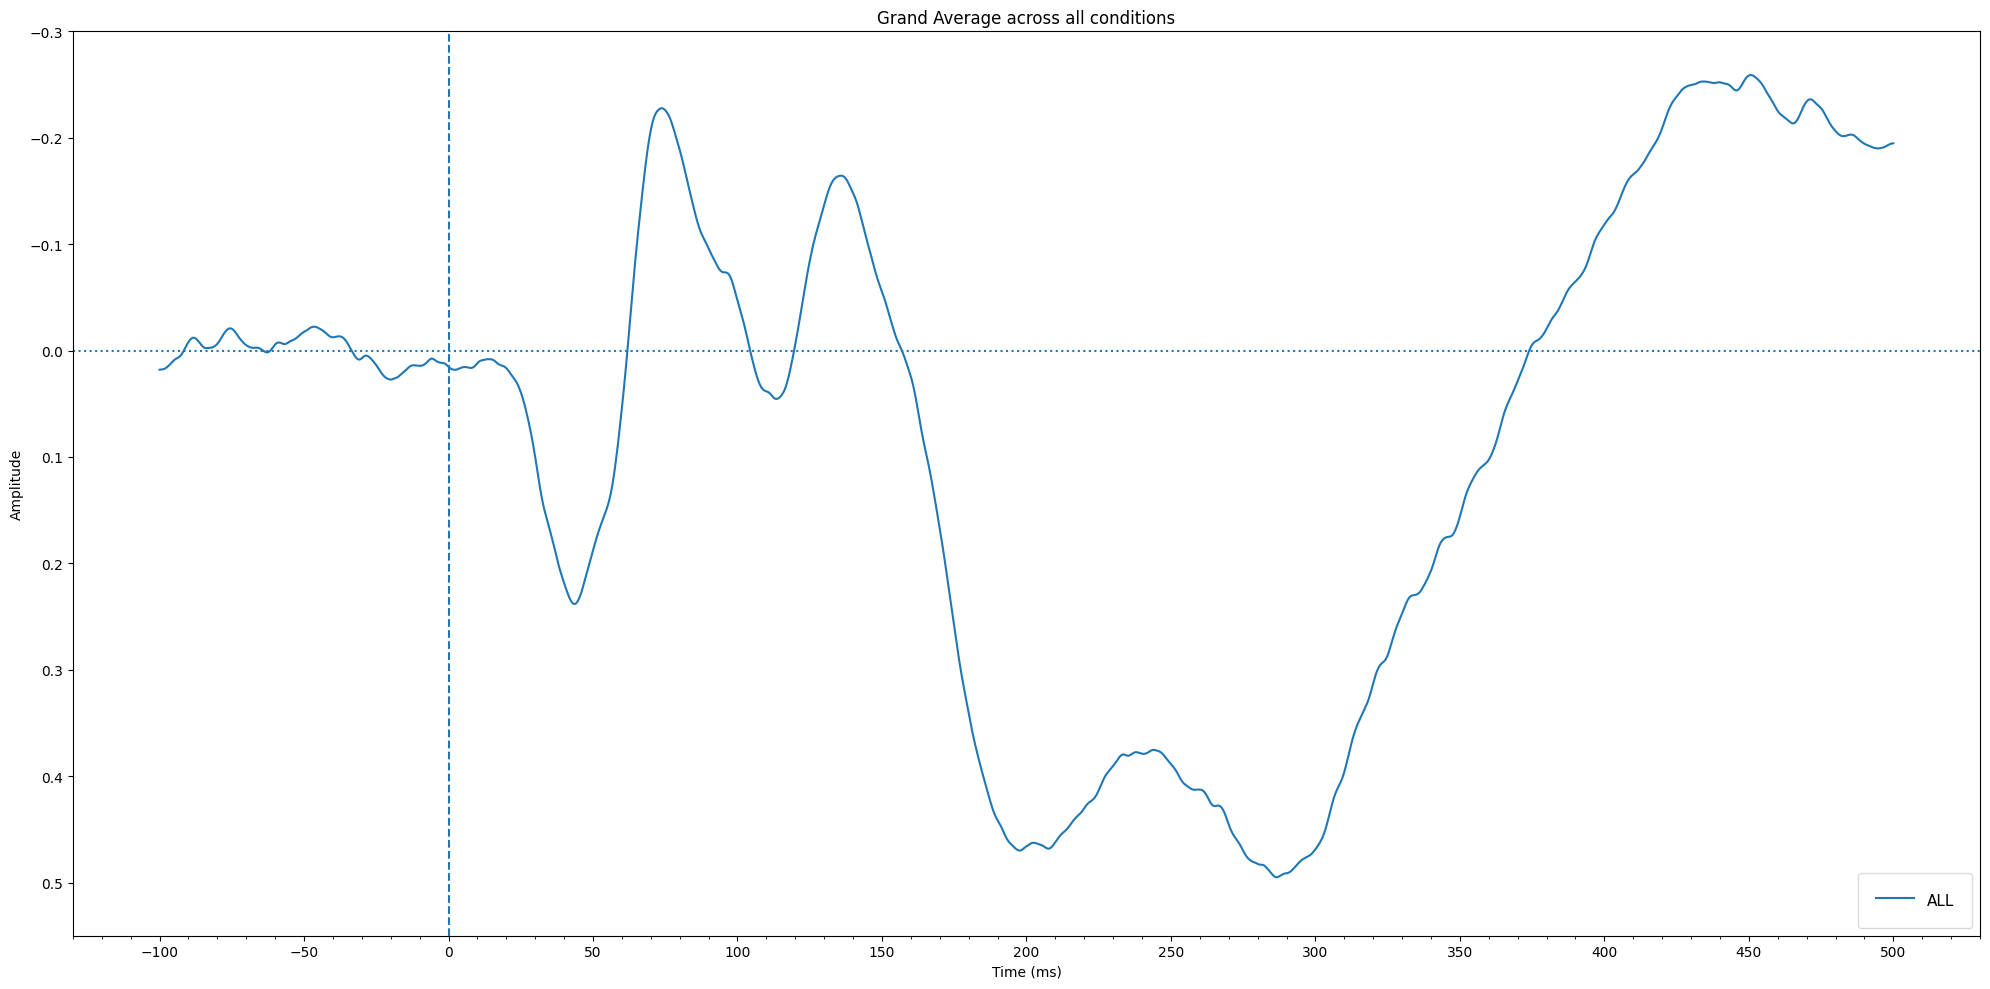

In [7]:
# Grand average 18 electrodes
channels_of_interest_18 = ["G6", "G7", "G8", "G11", "G12", "Y7", "Y8", "Y9", "Y11",
                         "G22", "G23", "G25", "G28", "G29", "Y22", "Y24", "Y25", "Y26"]

grand_averages_18 = {}
for condition, csv_file in csv_files.items():
    file_path = os.path.join(data_folder, csv_file)
    data_subset = load_eeg_subset(file_path, channels_of_interest_18)
    grand_averages_18[condition] = data_subset  # shape: (n_channels, n_timepoints)

plot_grand_averages(
    grand_averages_18,
    conditions=["ALL"],
    tmin=tmin,
    tmax=tmax,
    title="Grand Average across all conditions",
    ylim=(0.6, -0.4)
)

# Time windows

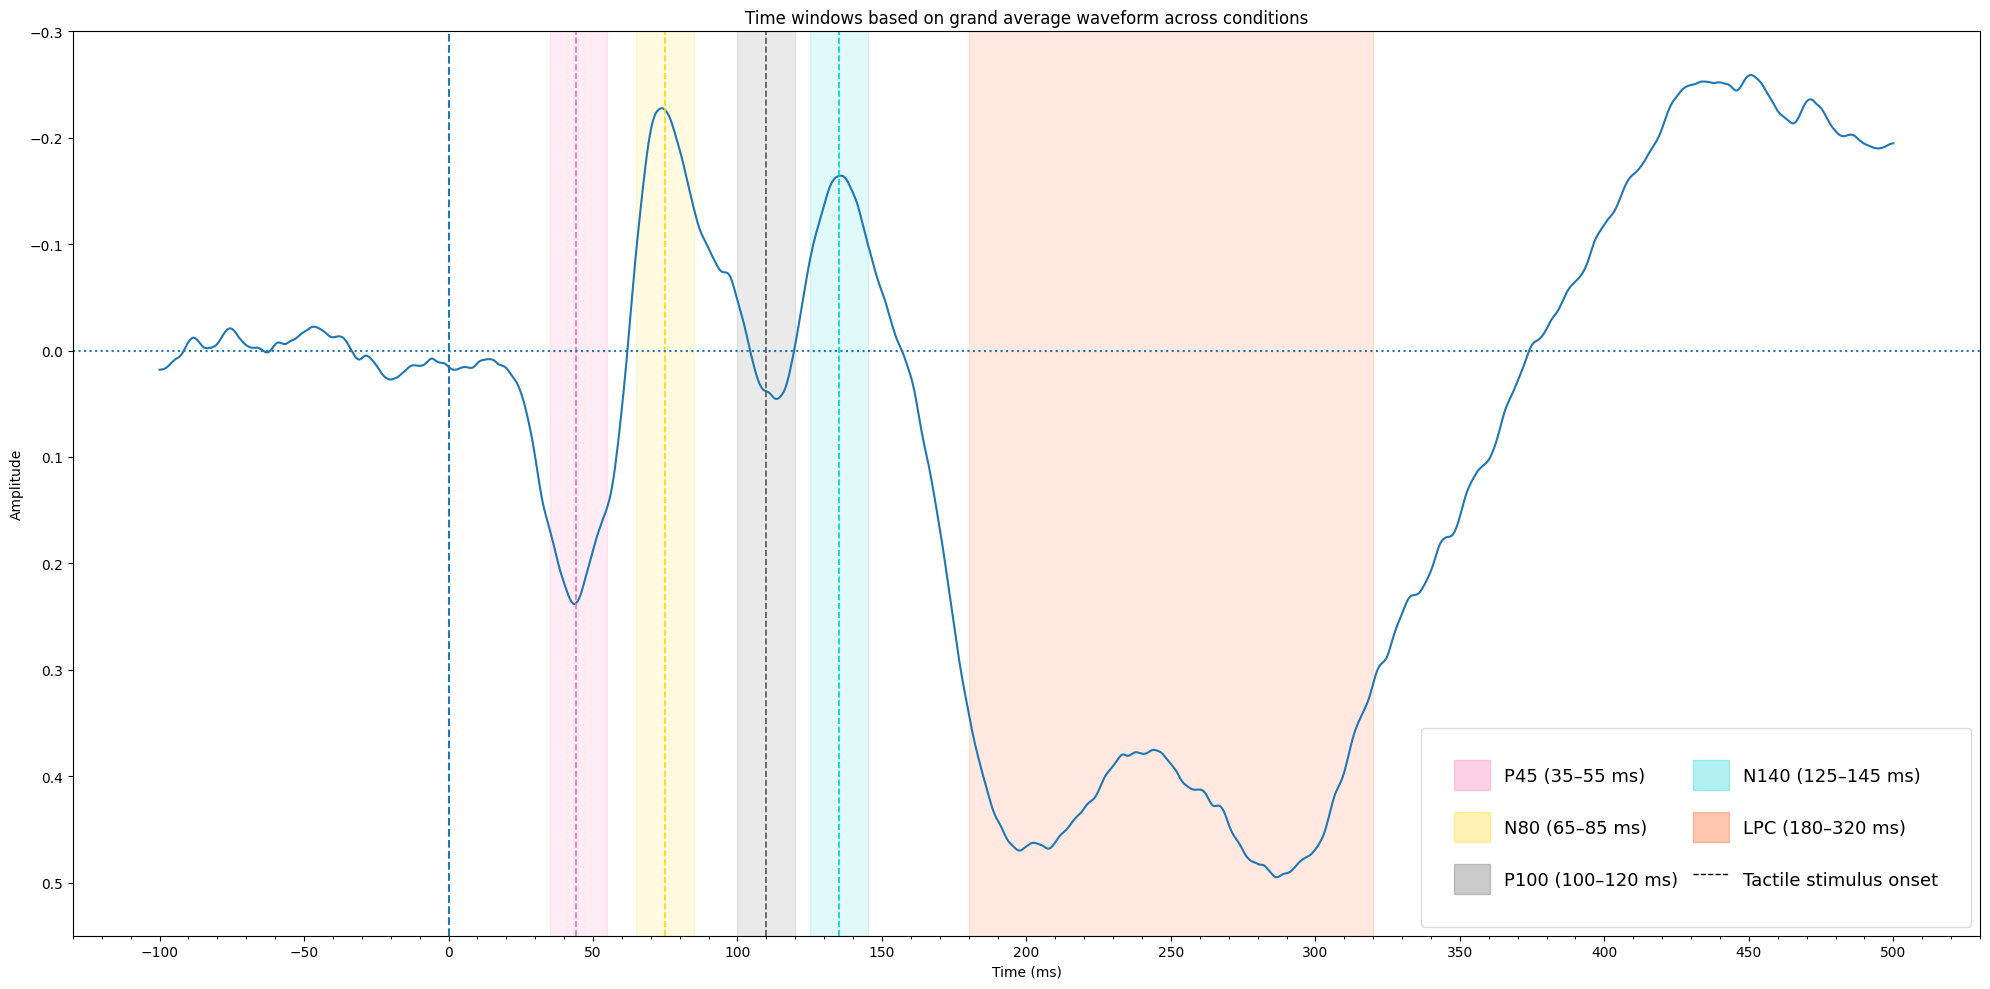

In [ ]:
from matplotlib.patches import Patch

def plot_time_windows():
    windows = {
        "P45":  ([35, 45, 55],    "#FF69B4"),
        "N80":  ([65, 75, 85],    "#FFD700"),
        "P100": ([100, 110, 120],  "#555555"),
        "N140": ([125, 135, 145], "#00CED1"),
        "LPC":  ([180, 250, 320],      "#FF4500"),
    }
    ax = plt.gca()
    component_names = list(windows.keys())
    for component, (times, color) in windows.items():
        t_start, t_end = times[0], times[-1]
        ax.axvspan(t_start, t_end, alpha=0.12, color=color)
        if component != component_names[-1]:
            t_mid = times[len(times) // 2]
            ax.axvline(t_mid, color=color, linewidth=1.2, linestyle="--",
                       label=f"{component} ({t_start}–{t_end} ms)")

# --- Data loading ---
channels_of_interest_18 = ["G6", "G7", "G8", "G11", "G12", "Y7", "Y8", "Y9", "Y11",
                            "G22", "G23", "G25", "G28", "G29", "Y22", "Y24", "Y25", "Y26"]
grand_averages_18 = {}
for condition, csv_file in csv_files.items():
    file_path = os.path.join(data_folder, csv_file)
    data_subset = load_eeg_subset(file_path, channels_of_interest_18)
    grand_avg = data_subset.mean(axis=0)
    grand_averages_18[condition] = grand_avg

n_timepoints = grand_averages_18["ALL"].shape[-1]
time = np.linspace(tmin, tmax, n_timepoints)

# --- Plot ---
plt.close("all")
plt.figure(figsize=(20, 10))

for cond in ["ALL"]:
    signal = grand_averages_18[cond]
    if signal.ndim == 2:
        signal = signal.mean(axis=0)
    plt.plot(time, signal, label=cond)

plot_time_windows()

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(50))
ax.xaxis.set_minor_locator(MultipleLocator(10))
# ax.set_title("Time windows based on grand average waveform across conditions")
ax.set_ylim(0.55, -0.3)
plt.axvline(0, linestyle="--")
plt.axhline(0, linestyle=":")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")

# --- Manual legend ---
window_entries = [
    Patch(facecolor=c, alpha=0.3, edgecolor=c,
          label=f"{comp} ({t[0]}–{t[-1]} ms)")
    for comp, (t, c) in {
        "P45":  ([35, 55],   "#FF69B4"),
        "N80":  ([65, 85],   "#FFD700"),
        "P100": ([100, 120],  "#555555"),
        "N140": ([125, 145], "#00CED1"),
        "LPC":  ([180, 320], "#FF4500"),
    }.items()
]

legend_meta = [
    Line2D([0], [0], color="black", linewidth=1, linestyle="--",
           label="Tactile stimulus onset"),
]

ax.legend(
    handles=window_entries + legend_meta,
    loc="lower right",
    fontsize=13,
    framealpha=0.7,
    ncol=2,
    handleheight=2.2,
    handlelength=2.0,        # ← reduced (was 3.0)
    borderpad=1.8,
    labelspacing=1.2,
    columnspacing=0.8,       # ← reduced (was 1.5)
    markerscale=1.5,
)

plt.tight_layout()
plt.show()

# Data preparation

## ✅ Convert .txt to .csv

In [21]:
def convert_sep_txt_to_csv(
    sep_name,
    conditions=("NST", "SNT", "ST")
):
    """
    Convert SEP .txt files to .csv when SEP folders are in the current directory.
    """

    # Input folder = SEP folder directly
    input_dir = Path(sep_name)

    # Output folder
    output_dir = Path(sep_name)
    output_dir.mkdir(parents=True, exist_ok=True)

    processed_files = []

    for condition in conditions:
        file_name = f"{sep_name}_{condition}.txt"
        file_path = input_dir / file_name

        try:
            df = pd.read_csv(file_path, sep=r"\s+", engine="python")

            output_file = output_dir / f"{file_path.stem}.csv"
            df.to_csv(output_file, index=False)

            processed_files.append(output_file)

            print(f"Processed: {file_name} → {output_file}")

        except FileNotFoundError:
            print(f"File not found: {file_path}")

        except Exception as e:
            print(f"Error processing {file_name}: {e}")

    print("Done.")
    return processed_files

seps = ["P45", "N80", "P100", "N140", "LPC"]

for sep in seps:
    convert_sep_txt_to_csv(sep)

Processed: P45_NST.txt → P45/P45_NST.csv
Processed: P45_SNT.txt → P45/P45_SNT.csv
Processed: P45_ST.txt → P45/P45_ST.csv
Done.
Processed: N80_NST.txt → N80/N80_NST.csv
Processed: N80_SNT.txt → N80/N80_SNT.csv
Processed: N80_ST.txt → N80/N80_ST.csv
Done.
Processed: P100_NST.txt → P100/P100_NST.csv
Processed: P100_SNT.txt → P100/P100_SNT.csv
Processed: P100_ST.txt → P100/P100_ST.csv
Done.
Processed: N140_NST.txt → N140/N140_NST.csv
Processed: N140_SNT.txt → N140/N140_SNT.csv
Processed: N140_ST.txt → N140/N140_ST.csv
Done.
Processed: LPC_NST.txt → LPC/LPC_NST.csv
Processed: LPC_SNT.txt → LPC/LPC_SNT.csv
Processed: LPC_ST.txt → LPC/LPC_ST.csv
Done.


## ✅ Full dataframe

In [3]:
def prepare_sep_data(
    sep_name,
    conditions=("ST", "SNT", "NST"),
    left_electrodes=None,
    right_electrodes=None
):

# 18 electrodes
    if left_electrodes is None:
        left_electrodes = ["G6", "G7", "G8", "G11", "G12", "Y7", "Y8", "Y9", "Y11"]

    if right_electrodes is None:
        right_electrodes = ["G22", "G23", "G25", "G28", "G29", "Y22", "Y24", "Y25", "Y26"]

    sep_dir = Path(sep_name)
    dataframes = []

    for condition in conditions:
        file_path = sep_dir / f"{sep_name}_{condition}.csv"
        df = pd.read_csv(file_path)

        df.columns = df.columns.str.replace(r"-.*$", "", regex=True)

        df = df.rename(columns={df.columns[0]: "participant"})
        df["participant"] = df["participant"].astype(str).str.extract(r"^(\d+)")

        df["condition"] = condition

        dataframes.append(df)

    combined_files = pd.concat(dataframes, ignore_index=True)

    # Keep only complete participants
    counts = combined_files.groupby("participant")["condition"].nunique()
    valid_participants = counts[counts == len(conditions)].index

    combined_files = combined_files[
        combined_files["participant"].isin(valid_participants)
    ]

    # Long format
    long_df = combined_files.melt(
        id_vars=["participant", "condition"],
        var_name="electrode",
        value_name="amplitude"
    )

    # Hemisphere mapping
    def get_hemi(e):
        if e in left_electrodes:
            return "Left"
        elif e in right_electrodes:
            return "Right"
        else:
            return np.nan

    long_df["hemisphere"] = long_df["electrode"].apply(get_hemi)

    df_full = long_df.dropna(subset=["hemisphere"])

    # Save full dataframe
    output_file = sep_dir / f"{sep_name}_HEMI.csv"
    df_full.to_csv(output_file, index=False)

    print(f"Saved: {output_file}")

    return df_full

In [4]:
prepare_sep_data("P45")
prepare_sep_data("N80")
prepare_sep_data("P100")
prepare_sep_data("N140")
prepare_sep_data("LPC")

Saved: P45/P45_HEMI.csv
Saved: N80/N80_HEMI.csv
Saved: P100/P100_HEMI.csv
Saved: N140/N140_HEMI.csv
Saved: LPC/LPC_HEMI.csv


,participant,condition,electrode,amplitude,hemisphere
450,1,ST,G6,-0.072333,Left
451,10,ST,G6,-0.431125,Left
452,11,ST,G6,0.511205,Left
453,12,ST,G6,-0.639706,Left
454,13,ST,G6,0.142844,Left
...,...,...,...,...,...
5125,4,NST,Y26,0.068395,Right
5126,5,NST,Y26,-0.381038,Right
5127,7,NST,Y26,1.794155,Right
5128,8,NST,Y26,0.080587,Right


# RM ANOVA Somatosensory Evoked Potentials' Amplitudes

In [5]:
def prepare_sep_anova_data(df_full):
    # Average within hemisphere (collapsing across electrodes)
    df_hemi = (
        df_full
        .groupby(["participant", "condition", "hemisphere"])["amplitude"]
        .mean()
        .reset_index()
    )
    return df_hemi

In [6]:
def detect_outliers_per_condition(
    df,
    value_col="amplitude",
    z_thresh=3,
    verbose=True
):
    df = df.copy()

    def compute_z(x):
        return (x - x.mean()) / x.std(ddof=0)

    df["zscore"] = df.groupby(["condition", "hemisphere"])[value_col].transform(compute_z)
    df["is_outlier"] = df["zscore"].abs() > z_thresh
    outlier_participants = df.loc[df["is_outlier"], "participant"].unique()

    if verbose:
        if len(outlier_participants) == 0:
            print("No outliers detected.")
        else:
            print("Outlier details (per condition x hemisphere cell):")
            print(df[df["is_outlier"]][["participant", "condition", "hemisphere", value_col, "zscore"]].to_string(index=False))
            print(f"\nParticipants flagged: {sorted(outlier_participants)}")

    return outlier_participants

In [7]:
def check_normality_rm(df_hemi, conditions=("ST", "SNT", "NST"), alpha=0.05):
    results = []
    hemispheres = df_hemi["hemisphere"].unique()

    for hemi in hemispheres:
        temp = (
            df_hemi[df_hemi["hemisphere"] == hemi]
            .pivot(index="participant", columns="condition", values="amplitude")
        )

        if not all(cond in temp.columns for cond in conditions):
            print(f"Missing conditions in hemisphere: {hemi}")
            continue

        diffs = {
            f"{conditions[0]}-{conditions[1]}": temp[conditions[0]] - temp[conditions[1]],
            f"{conditions[0]}-{conditions[2]}": temp[conditions[0]] - temp[conditions[2]],
            f"{conditions[1]}-{conditions[2]}": temp[conditions[1]] - temp[conditions[2]],
        }

        for name, diff in diffs.items():
            diff_clean = diff.dropna()
            stat, p = shapiro(diff_clean)
            results.append((hemi, name, stat, p))

    normality_results = pd.DataFrame(
        results,
        columns=["hemisphere", "comparison", "W_stat", "p_value"]
    )
    return normality_results

In [8]:
def check_sphericity_rm(df_hemi, sep_name=None):
    sphericity = pg.sphericity(
        data=df_hemi,
        dv="amplitude",
        subject="participant",
        within=["condition", "hemisphere"]
    )

    if sep_name:
        print(f"\nSphericity results for {sep_name}:")
    print(sphericity)

    return sphericity

In [9]:
def run_anova(df_hemi, sep_name=None):
    anova = pg.rm_anova(
        data=df_hemi,
        dv="amplitude",
        within=["condition", "hemisphere"],
        subject="participant",
        detailed=True, 
        correction = True
    )
    label = sep_name if sep_name else "SEP"
    print(f"\nRM ANOVA results for {label}:")
    print(anova.to_string())
    return anova

## Data preparation

In [10]:
p45_hemi  = prepare_sep_anova_data(prepare_sep_data("P45"))
n80_hemi  = prepare_sep_anova_data(prepare_sep_data("N80"))
p100_hemi = prepare_sep_anova_data(prepare_sep_data("P100"))
n140_hemi = prepare_sep_anova_data(prepare_sep_data("N140"))
lpc_hemi  = prepare_sep_anova_data(prepare_sep_data("LPC"))

Saved: P45/P45_HEMI.csv
Saved: N80/N80_HEMI.csv
Saved: P100/P100_HEMI.csv
Saved: N140/N140_HEMI.csv
Saved: LPC/LPC_HEMI.csv


## Outliers

In [11]:
# Detect outliers across all SEPs
outliers_p45  = detect_outliers_per_condition(p45_hemi,  verbose=True)
outliers_n80  = detect_outliers_per_condition(n80_hemi,  verbose=True)
outliers_p100 = detect_outliers_per_condition(p100_hemi, verbose=True)
outliers_n140 = detect_outliers_per_condition(n140_hemi, verbose=True)
outliers_lpc  = detect_outliers_per_condition(lpc_hemi,  verbose=True)

# Pool all outlier participant IDs
all_outliers = set(outliers_p45) | set(outliers_n80) | set(outliers_p100) | set(outliers_n140) | set(outliers_lpc)
print(f"\nAll participants removed across any SEP: {sorted(all_outliers)}")
print(f"Total removed: {len(all_outliers)}")

# Apply to all SEPs
p45_clean  = p45_hemi[~p45_hemi["participant"].isin(all_outliers)].reset_index(drop=True)
n80_clean  = n80_hemi[~n80_hemi["participant"].isin(all_outliers)].reset_index(drop=True)
p100_clean = p100_hemi[~p100_hemi["participant"].isin(all_outliers)].reset_index(drop=True)
n140_clean = n140_hemi[~n140_hemi["participant"].isin(all_outliers)].reset_index(drop=True)
lpc_clean  = lpc_hemi[~lpc_hemi["participant"].isin(all_outliers)].reset_index(drop=True)

print(f"\nFinal N participants: {p45_clean['participant'].nunique()}")

No outliers detected.
No outliers detected.
No outliers detected.
Outlier details (per condition x hemisphere cell):
participant condition hemisphere  amplitude    zscore
         19        ST      Right   2.078816  3.098004
         23       SNT       Left  -2.552541 -3.370871
         23        ST       Left  -2.651485 -3.243986

Participants flagged: ['19', '23']
Outlier details (per condition x hemisphere cell):
participant condition hemisphere  amplitude   zscore
         30       NST      Right   1.798458 3.218882

Participants flagged: ['30']

All participants removed across any SEP: ['19', '23', '30']
Total removed: 3

Final N participants: 27


## Normality

In [12]:
check_normality_rm(p45_clean)

,hemisphere,comparison,W_stat,p_value
0,Left,ST-SNT,0.945866,0.169929
1,Left,ST-NST,0.958105,0.334330
2,Left,SNT-NST,0.942112,0.137371
3,Right,ST-SNT,0.978849,0.835463
4,Right,ST-NST,0.946773,0.178851
5,Right,SNT-NST,0.943442,0.148137


In [13]:
check_normality_rm(n80_clean)

,hemisphere,comparison,W_stat,p_value
0,Left,ST-SNT,0.957726,0.327628
1,Left,ST-NST,0.957952,0.331611
2,Left,SNT-NST,0.982549,0.914815
3,Right,ST-SNT,0.957289,0.320035
4,Right,ST-NST,0.961282,0.395123
5,Right,SNT-NST,0.978555,0.828344


In [14]:
check_normality_rm(p100_clean)

,hemisphere,comparison,W_stat,p_value
0,Left,ST-SNT,0.932252,0.078491
1,Left,ST-NST,0.884388,0.005983
2,Left,SNT-NST,0.919986,0.039449
3,Right,ST-SNT,0.953918,0.266426
4,Right,ST-NST,0.972207,0.660923
5,Right,SNT-NST,0.952774,0.250147


In [15]:
check_normality_rm(n140_clean)

,hemisphere,comparison,W_stat,p_value
0,Left,ST-SNT,0.920959,0.041638
1,Left,ST-NST,0.806585,0.000178
2,Left,SNT-NST,0.819058,0.000298
3,Right,ST-SNT,0.956269,0.302897
4,Right,ST-NST,0.967301,0.532300
5,Right,SNT-NST,0.974341,0.718741


In [16]:
check_normality_rm(lpc_clean)

,hemisphere,comparison,W_stat,p_value
0,Left,ST-SNT,0.988160,0.984916
1,Left,ST-NST,0.961860,0.407075
2,Left,SNT-NST,0.973322,0.691156
3,Right,ST-SNT,0.991104,0.997066
4,Right,ST-NST,0.976181,0.767894
5,Right,SNT-NST,0.972938,0.680747


## Sphericity

In [17]:
check_sphericity_rm(p45_clean, "P45")
check_sphericity_rm(n80_clean, "N80")
check_sphericity_rm(p100_clean, "P100")
check_sphericity_rm(n140_clean, "N140")
check_sphericity_rm(lpc_clean, "LPC")


Sphericity results for P45:
SpherResults(spher=False, W=np.float64(0.6146786459633381), chi2=np.float64(12.166391865731242), dof=2, pval=np.float64(0.00228087546721894))

Sphericity results for N80:
SpherResults(spher=True, W=np.float64(0.9083417761760019), chi2=np.float64(2.4033641430859185), dof=2, pval=np.float64(0.3006880075547658))

Sphericity results for P100:
SpherResults(spher=True, W=np.float64(0.9322843740080883), chi2=np.float64(1.7529347127655284), dof=2, pval=np.float64(0.4162507830938261))

Sphericity results for N140:
SpherResults(spher=True, W=np.float64(0.8505866391002318), chi2=np.float64(4.04572509759623), dof=2, pval=np.float64(0.13227627532151634))

Sphericity results for LPC:
SpherResults(spher=False, W=np.float64(0.7622466593441364), chi2=np.float64(6.787126893708018), dof=2, pval=np.float64(0.033588771585909505))


SpherResults(spher=False, W=np.float64(0.7622466593441364), chi2=np.float64(6.787126893708018), dof=2, pval=np.float64(0.033588771585909505))

## ANOVA

In [18]:
run_anova(p45_clean)


RM ANOVA results for SEP:
                   Source        SS  ddof1  ddof2        MS         F     p_unc  p_GG_corr       ng2       eps
0               condition  0.332189      2     52  0.166094  2.754991  0.072906   0.073684  0.014624  0.987290
1              hemisphere  0.998352      1     26  0.998352  3.959321  0.057226   0.057226  0.042699  1.000000
2  condition * hemisphere  0.086269      2     52  0.043135  0.421624  0.658203   0.593606  0.003839  0.721854


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,ng2,eps
0,condition,0.332189,2,52,0.166094,2.754991,0.072906,0.073684,0.014624,0.987290
1,hemisphere,0.998352,1,26,0.998352,3.959321,0.057226,0.057226,0.042699,1.000000
2,condition * hemisphere,0.086269,2,52,0.043135,0.421624,0.658203,0.593606,0.003839,0.721854


In [19]:
run_anova(n80_clean)


RM ANOVA results for SEP:
                   Source        SS  ddof1  ddof2        MS          F     p_unc  p_GG_corr       ng2       eps
0               condition  0.041084      2     52  0.020542   0.321334  0.726611   0.700237  0.001034  0.884496
1              hemisphere  4.590149      1     26  4.590149  11.326639  0.002383   0.002383  0.103671  1.000000
2  condition * hemisphere  0.095519      2     52  0.047759   0.586669  0.559816   0.545781  0.002401  0.916038


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,ng2,eps
0,condition,0.041084,2,52,0.020542,0.321334,0.726611,0.700237,0.001034,0.884496
1,hemisphere,4.590149,1,26,4.590149,11.326639,0.002383,0.002383,0.103671,1.000000
2,condition * hemisphere,0.095519,2,52,0.047759,0.586669,0.559816,0.545781,0.002401,0.916038


In [20]:
run_anova(p100_clean)


RM ANOVA results for SEP:
                   Source        SS  ddof1  ddof2        MS         F     p_unc  p_GG_corr       ng2       eps
0               condition  0.022154      2     52  0.011077  0.171488  0.842885   0.834862  0.000358  0.961808
1              hemisphere  0.003312      1     26  0.003312  0.005678  0.940509   0.940509  0.000054  1.000000
2  condition * hemisphere  0.215300      2     52  0.107650  0.743289  0.480531   0.472634  0.003467  0.936579


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,ng2,eps
0,condition,0.022154,2,52,0.011077,0.171488,0.842885,0.834862,0.000358,0.961808
1,hemisphere,0.003312,1,26,0.003312,0.005678,0.940509,0.940509,0.000054,1.000000
2,condition * hemisphere,0.215300,2,52,0.107650,0.743289,0.480531,0.472634,0.003467,0.936579


In [21]:
run_anova(n140_clean)


RM ANOVA results for SEP:
                   Source        SS  ddof1  ddof2        MS         F     p_unc  p_GG_corr       ng2       eps
0               condition  0.114758      2     52  0.057379  0.696438  0.502945   0.486746  0.001950  0.884686
1              hemisphere  0.674304      1     26  0.674304  1.550046  0.224234   0.224234  0.011351  1.000000
2  condition * hemisphere  0.061633      2     52  0.030817  0.269970  0.764466   0.733947  0.001048  0.870009


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,ng2,eps
0,condition,0.114758,2,52,0.057379,0.696438,0.502945,0.486746,0.001950,0.884686
1,hemisphere,0.674304,1,26,0.674304,1.550046,0.224234,0.224234,0.011351,1.000000
2,condition * hemisphere,0.061633,2,52,0.030817,0.269970,0.764466,0.733947,0.001048,0.870009


In [22]:
run_anova(lpc_clean)


RM ANOVA results for SEP:
                   Source        SS  ddof1  ddof2        MS         F     p_unc  p_GG_corr       ng2       eps
0               condition  0.054682      2     52  0.027341  0.460983  0.633216   0.580022  0.001975  0.755355
1              hemisphere  1.764637      1     26  1.764637  5.680619  0.024745   0.024745  0.060040  1.000000
2  condition * hemisphere  0.084860      2     52  0.042430  0.727333  0.488046   0.461486  0.003062  0.807915


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,ng2,eps
0,condition,0.054682,2,52,0.027341,0.460983,0.633216,0.580022,0.001975,0.755355
1,hemisphere,1.764637,1,26,1.764637,5.680619,0.024745,0.024745,0.060040,1.000000
2,condition * hemisphere,0.084860,2,52,0.042430,0.727333,0.488046,0.461486,0.003062,0.807915


## Post hoc sensitivity analysis

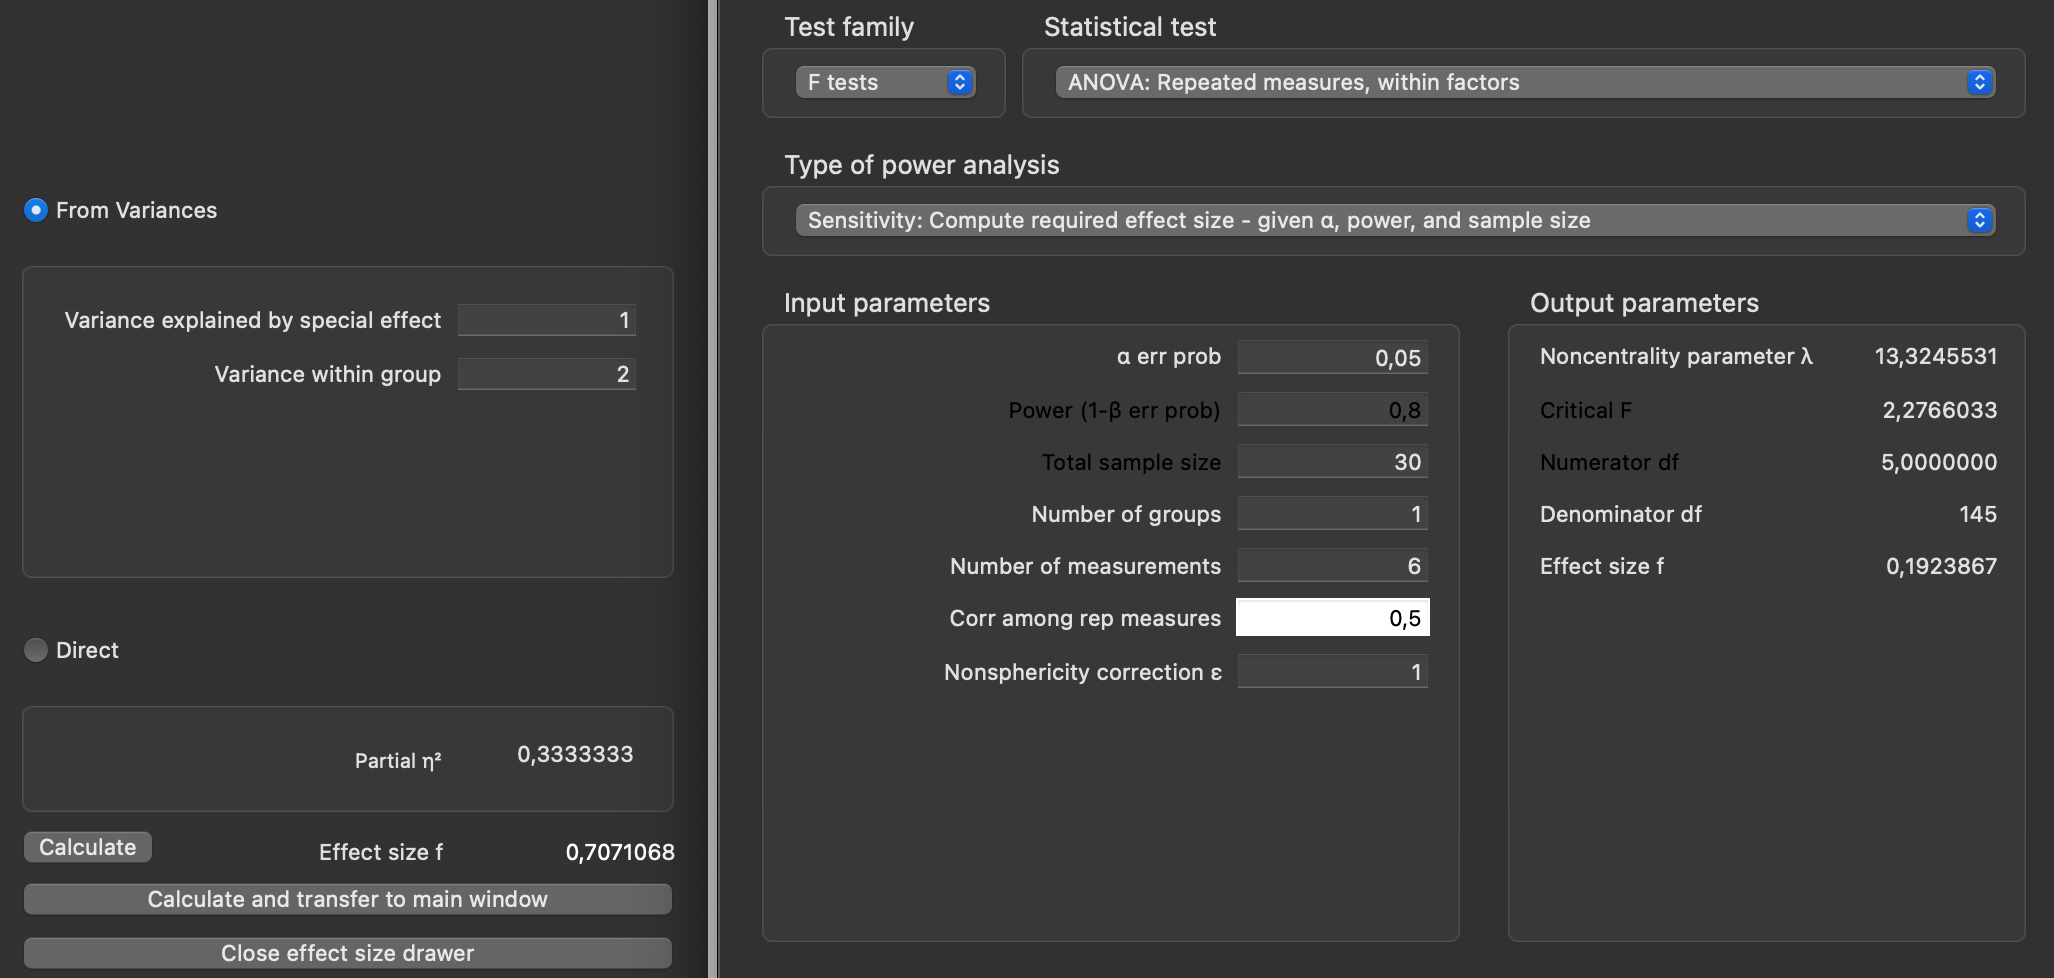

# Plots

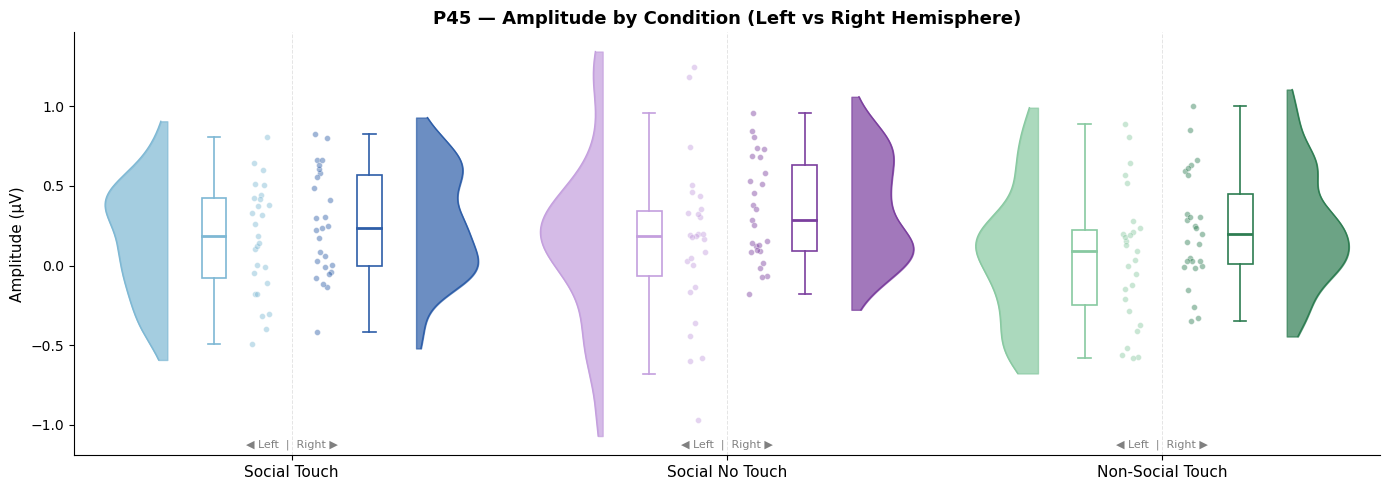

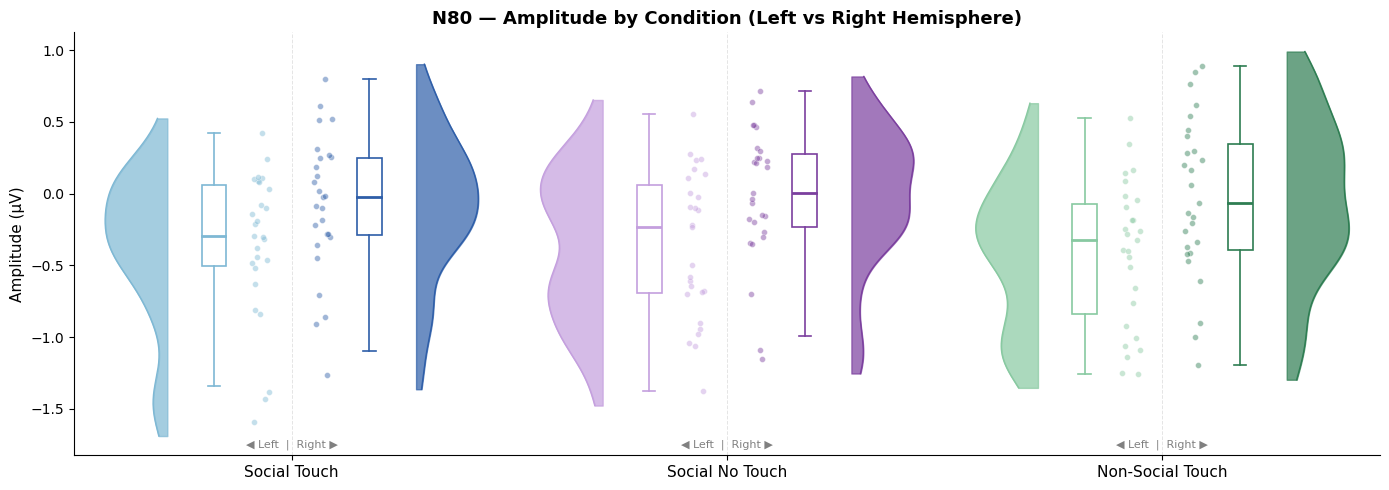

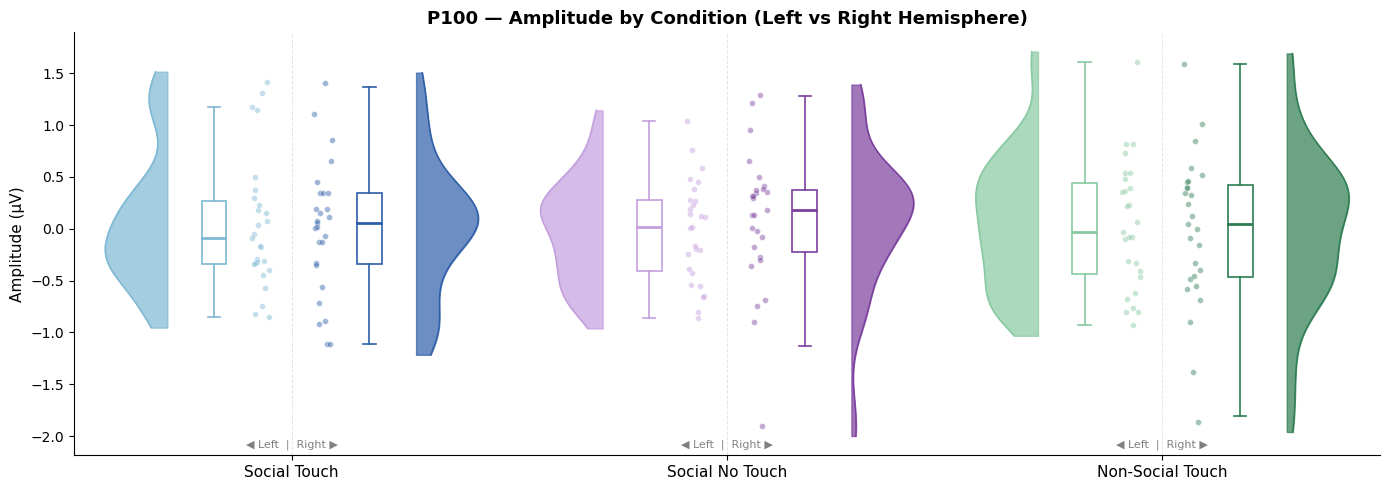

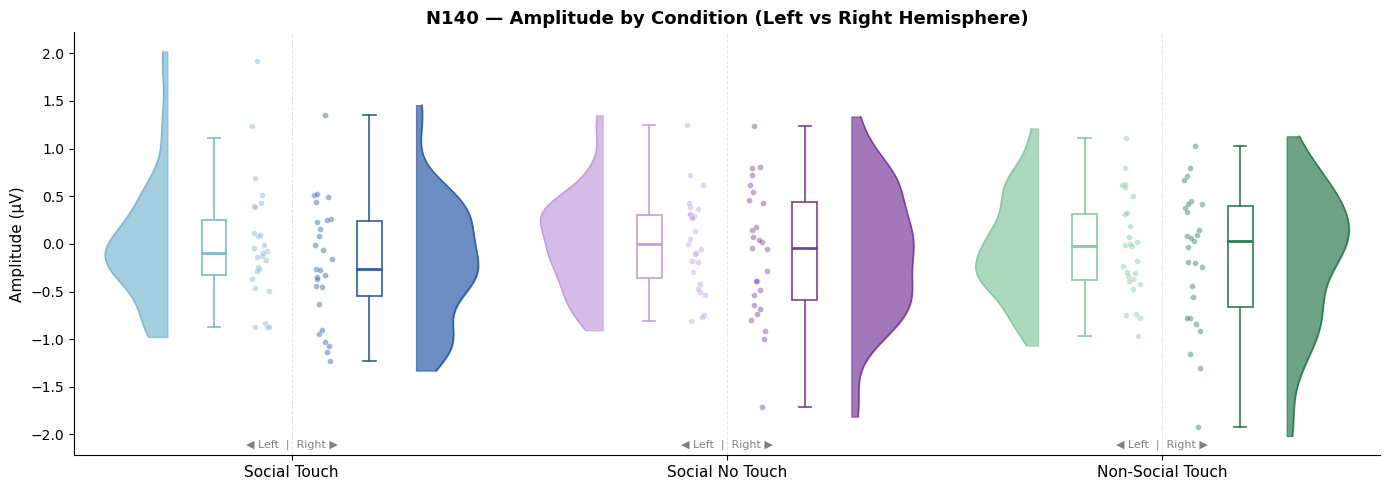

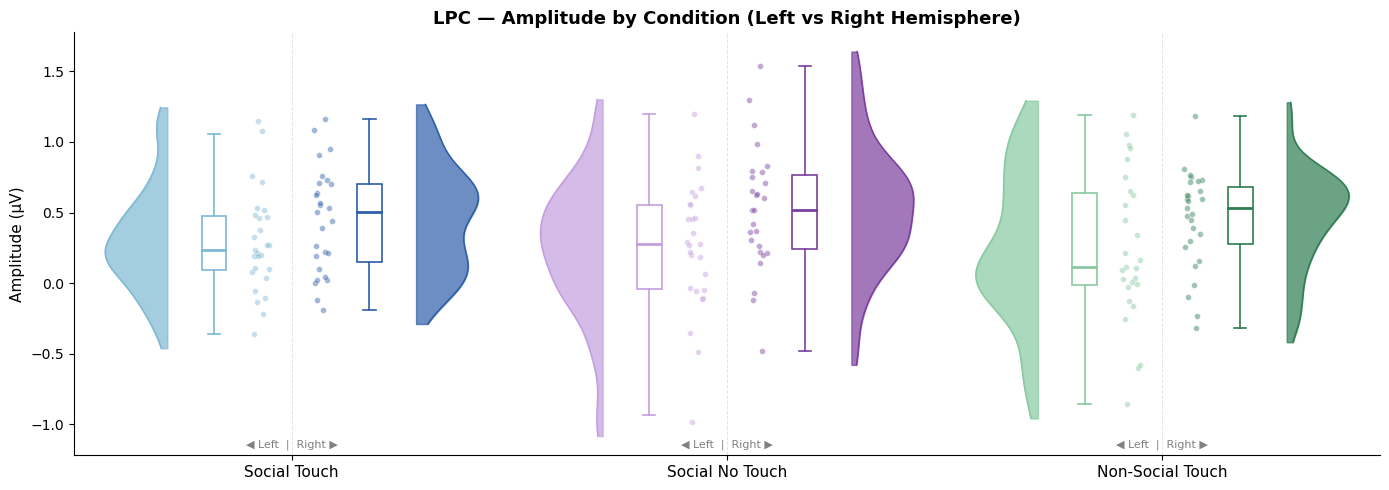

In [23]:
def raincloud_plot_paired(df, sep_name, conditions=("ST", "SNT", "NST"),
                          condition_labels=None, palette=None):
    if condition_labels is None:
        condition_labels = {"ST": "Social Touch",
                            "SNT": "Social No Touch",
                            "NST": "Non-Social Touch"}
    # palette: dict keyed by (condition, hemisphere)
    if palette is None:
        palette = {
            ("ST",  "Left"):  "#7EB8D4",
            ("ST",  "Right"): "#2E5EA8",
            ("SNT", "Left"):  "#C49FDE",
            ("SNT", "Right"): "#7B3F9E",
            ("NST", "Left"):  "#88C9A1",
            ("NST", "Right"): "#2E7D52",
        }

    collapsed = (df.groupby(["participant", "condition", "hemisphere"])["amplitude"]
                   .mean()
                   .reset_index())

    fig, ax = plt.subplots(figsize=(14, 5))

    spacing    = 1.4
    jitter     = 0.03
    vio_width  = 0.2
    box_width  = 0.08
    dot_offset = 0.10
    box_offset = 0.25
    vio_offset = 0.4

    for i, cond in enumerate(conditions):
        x_center = i * spacing

        for side, hemi, mirror in [(-1, "Left", True), (1, "Right", False)]:
            data = (collapsed[(collapsed["condition"] == cond) &
                               (collapsed["hemisphere"] == hemi)]["amplitude"].values)
            if len(data) == 0:
                continue

            color = palette[(cond, hemi)]

            # ── Individual points ─────────────────────────────────────────────
            np.random.seed(42)
            x_dots = x_center + side * dot_offset
            x_jitter = x_dots + np.random.uniform(-jitter, jitter, size=len(data))
            ax.scatter(x_jitter, data, color=color, alpha=0.45, s=18, zorder=2,
                       linewidths=0.5, edgecolors="white")

            # ── Boxplot ───────────────────────────────────────────────────────
            x_box = x_center + side * box_offset

            q1, median, q3 = np.percentile(data, [25, 50, 75])
            iqr = q3 - q1
            whisker_low  = max(data.min(), q1 - 1.5 * iqr)
            whisker_high = min(data.max(), q3 + 1.5 * iqr)

            ax.add_patch(mpatches.FancyBboxPatch(
                (x_box - box_width / 2, q1),
                box_width, iqr,
                boxstyle="square,pad=0",
                linewidth=1.2,
                edgecolor=color,
                facecolor="white",
                zorder=3
            ))
            ax.plot([x_box - box_width / 2 + 0.001, x_box + box_width / 2 - 0.004],
                    [median, median], color=color, linewidth=2, zorder=4)
            ax.plot([x_box, x_box], [whisker_low, q1],
                    color=color, linewidth=1.2, zorder=3)
            ax.plot([x_box, x_box], [q3, whisker_high],
                    color=color, linewidth=1.2, zorder=3)
            for w in [whisker_low, whisker_high]:
                ax.plot([x_box - box_width / 4, x_box + box_width / 4],
                        [w, w], color=color, linewidth=1.2, zorder=3)

            # ── Half-violin ───────────────────────────────────────────────────
            x_vio = x_center + side * vio_offset

            kde = gaussian_kde(data, bw_method=0.4)
            y_range = np.linspace(data.min() - 0.1, data.max() + 0.1, 200)
            kde_vals = kde(y_range)
            kde_vals = kde_vals / kde_vals.max() * vio_width

            if mirror:
                ax.fill_betweenx(y_range, x_vio, x_vio - kde_vals,
                                 alpha=0.7, color=color)
                ax.plot(x_vio - kde_vals, y_range, color=color, linewidth=1)
            else:
                ax.fill_betweenx(y_range, x_vio, x_vio + kde_vals,
                                 alpha=0.7, color=color)
                ax.plot(x_vio + kde_vals, y_range, color=color, linewidth=1)

    # ── Vertical divider ─────────────────────────────────────────────────────
    for i in range(len(conditions)):
        ax.axvline(x=i * spacing, color='lightgray', linewidth=0.7,
                   linestyle='--', zorder=1, alpha=0.6)

    # ── Legend ────────────────────────────────────────────────────────────────
    for i, cond in enumerate(conditions):
        ax.annotate('◀ Left  |  Right ▶',
                    xy=(i * spacing, 0), xycoords=('data', 'axes fraction'),
                    ha='center', va='bottom', fontsize=8, color='gray',
                    xytext=(0, 4), textcoords='offset points')

    # ── Axes formatting ───────────────────────────────────────────────────────
    ax.set_xticks([i * spacing for i in range(len(conditions))])
    ax.set_xticklabels([condition_labels[c] for c in conditions], fontsize=11)
    ax.set_ylabel("Amplitude (µV)", fontsize=11)
    ax.set_title(f"{sep_name} — Amplitude by Condition (Left vs Right Hemisphere)",
                 fontsize=13, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(-(vio_offset + vio_width + 0.1),
                (len(conditions) - 1) * spacing + vio_offset + vio_width + 0.1)

    plt.tight_layout()
    # save_name = f"{sep_name}_raincloud_paired.png"
    # plt.savefig(save_name, dpi=300, bbox_inches="tight")
    # plt.show()
    # print(f"Saved: {save_name}")


# ── Run ───────────────────────────────────────────────────────────────────────
for name, df in [("P45",  p45_clean),  ("N80",  n80_clean),
                 ("P100", p100_clean), ("N140", n140_clean),
                 ("LPC",  lpc_clean)]:
    raincloud_plot_paired(df, name)

# JASP EXPORT

In [24]:
def prepare_jasp_export_all(sep_names, output_dir=None):
    hemi_data = {}
    for sep_name in sep_names:
        df_full = prepare_sep_data(sep_name)
        hemi_data[sep_name] = prepare_sep_anova_data(df_full)

    # Pool outliers across all SEPs (same logic as Python ANOVA pipeline)
    all_outliers = set()
    for sep_name, df_hemi in hemi_data.items():
        outliers = detect_outliers_per_condition(df_hemi, verbose=True)
        all_outliers |= set(outliers)

    print(f"\nAll participants removed across any SEP: {sorted(all_outliers)}")
    print(f"Total removed: {len(all_outliers)}")

    # Export each SEP with the same participants removed
    for sep_name, df_hemi in hemi_data.items():
        df_clean = df_hemi[~df_hemi["participant"].isin(all_outliers)]
        df_wide = df_clean.pivot_table(
            index="participant",
            columns=["condition", "hemisphere"],
            values="amplitude"
        )
        df_wide.columns = [f"{cond}_{hemi}" for cond, hemi in df_wide.columns]
        df_wide = df_wide.reset_index()

        out_dir = Path(output_dir) if output_dir else Path(sep_name)
        output_path = out_dir / f"{sep_name}_JASP.csv"
        df_wide.to_csv(output_path, index=False)
        print(f"Saved {sep_name}: {len(df_wide)} participants → {output_path}")

In [25]:
prepare_jasp_export_all(["P45", "N80", "P100", "N140", "LPC"])

Saved: P45/P45_HEMI.csv
Saved: N80/N80_HEMI.csv
Saved: P100/P100_HEMI.csv
Saved: N140/N140_HEMI.csv
Saved: LPC/LPC_HEMI.csv
No outliers detected.
No outliers detected.
No outliers detected.
Outlier details (per condition x hemisphere cell):
participant condition hemisphere  amplitude    zscore
         19        ST      Right   2.078816  3.098004
         23       SNT       Left  -2.552541 -3.370871
         23        ST       Left  -2.651485 -3.243986

Participants flagged: ['19', '23']
Outlier details (per condition x hemisphere cell):
participant condition hemisphere  amplitude   zscore
         30       NST      Right   1.798458 3.218882

Participants flagged: ['30']

All participants removed across any SEP: ['19', '23', '30']
Total removed: 3
Saved P45: 27 participants → P45/P45_JASP.csv
Saved N80: 27 participants → N80/N80_JASP.csv
Saved P100: 27 participants → P100/P100_JASP.csv
Saved N140: 27 participants → N140/N140_JASP.csv
Saved LPC: 27 participants → LPC/LPC_JASP.csv


# Exploratory RM ANOVAS by Region 

In [26]:
# Region mapping: 3 electrodes per region, 3 regions per hemisphere
region_map = {
    # Left hemisphere
    "G6": "Fronto-Central",  "Y7": "Fronto-Central",  "G7": "Fronto-Central",
    "Y9": "Central",         "G8": "Central",         "Y8": "Central",
    "G11": "Centro-Parietal","Y11": "Centro-Parietal","G12": "Centro-Parietal",
    # Right hemisphere
    "G29": "Fronto-Central", "Y26": "Fronto-Central", "G28": "Fronto-Central",
    "Y25": "Central",        "G25": "Central",        "Y24": "Central",
    "G23": "Centro-Parietal","Y22": "Centro-Parietal","G22": "Centro-Parietal",
}


def prepare_sep_region_data(df_full, region_map):
    """
    Average amplitude within each (hemisphere, region) cell.
    Takes df_full from prepare_sep_data() — long format with hemisphere already assigned.
    """
    df = df_full.copy()
    df["region"] = df["electrode"].map(region_map)
    df = df.dropna(subset=["region"])

    df_region = (
        df.groupby(["participant", "condition", "hemisphere", "region"])["amplitude"]
          .mean()
          .reset_index()
    )
    return df_region


def export_region_jasp(df_region, sep_name, output_dir=None):
    """Wide-format export: condition × hemisphere × region columns per participant."""
    df_wide = df_region.pivot_table(
        index="participant",
        columns=["condition", "hemisphere", "region"],
        values="amplitude"
    )
    df_wide.columns = [f"{cond}_{hemi}_{reg}" for cond, hemi, reg in df_wide.columns]
    df_wide = df_wide.reset_index()

    out_dir = Path(output_dir) if output_dir else Path(sep_name)
    output_path = out_dir / f"{sep_name}_REGION_JASP.csv"
    df_wide.to_csv(output_path, index=False)
    print(f"Saved {sep_name}: {len(df_wide)} participants → {output_path}")
    return df_wide

In [27]:
# Rebuild long-format dfs (cheap — just reads the CSVs you already have)
p45_full  = prepare_sep_data("p45")
n80_full  = prepare_sep_data("n80")
p100_full = prepare_sep_data("p100")
n140_full = prepare_sep_data("n140")
lpc_full  = prepare_sep_data("lpc")

# Build region-level dfs and drop the SAME outlier participants
def make_region_clean(df_full, sep_name):
    df_region = prepare_sep_region_data(df_full, region_map)
    df_clean = df_region[~df_region["participant"].isin(all_outliers)].reset_index(drop=True)
    export_region_jasp(df_clean, sep_name)
    return df_clean

p45_region  = make_region_clean(p45_full,  "p45")
n80_region  = make_region_clean(n80_full,  "n80")
p100_region = make_region_clean(p100_full, "p100")
n140_region = make_region_clean(n140_full, "n140")
lpc_region  = make_region_clean(lpc_full,  "lpc")

print(f"\nFinal N participants (region-level): {p45_region['participant'].nunique()}")

Saved: p45/p45_HEMI.csv
Saved: n80/n80_HEMI.csv
Saved: p100/p100_HEMI.csv
Saved: n140/n140_HEMI.csv
Saved: lpc/lpc_HEMI.csv
Saved p45: 27 participants → p45/p45_REGION_JASP.csv
Saved n80: 27 participants → n80/n80_REGION_JASP.csv
Saved p100: 27 participants → p100/p100_REGION_JASP.csv
Saved n140: 27 participants → n140/n140_REGION_JASP.csv
Saved lpc: 27 participants → lpc/lpc_REGION_JASP.csv

Final N participants (region-level): 27
